In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
data = pd.read_csv("housing.csv")

In [3]:
data.info()           #to see if there is some null values if there is then its a problem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
data.dropna(inplace=True)         #to drop any null values from the data

In [5]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


## Now split the data into training set and test data and x and y

In [6]:
from sklearn.model_selection import train_test_split
#define x and y first to be splited them afterwards into Xtrain and Xtest and same for Y

x = data.drop(['median_house_value'],axis=1)    # drop the target variable 'median_house_value'
y = data['median_house_value']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)   #this 20% we are not going to use untill we are confidant from the model and the para and ready to launch it

In [8]:
train_data = x_train.join(y_train)
#After executing train_data = x_train.join(y_train), we'll have a single DataFrame (train_data) that contains both the features and the target variable, which can be convenient for further analysis or modeling tasks.
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
8941,-118.46,34.01,48.0,1640.0,322.0,664.0,301.0,4.0000,<1H OCEAN,500001.0
18184,-122.04,37.37,33.0,2757.0,489.0,1201.0,481.0,5.0453,<1H OCEAN,311600.0
3442,-118.40,34.25,13.0,1872.0,497.0,1927.0,432.0,2.2019,<1H OCEAN,134200.0
18142,-122.05,37.34,31.0,1443.0,215.0,627.0,222.0,6.6087,<1H OCEAN,416500.0
37,-122.28,37.83,52.0,1511.0,390.0,901.0,403.0,1.4103,NEAR BAY,103900.0
...,...,...,...,...,...,...,...,...,...,...
6321,-117.98,34.00,22.0,3632.0,538.0,1968.0,566.0,6.0190,<1H OCEAN,324900.0
9051,-118.12,34.71,26.0,4230.0,823.0,2789.0,793.0,2.5179,INLAND,104000.0
19907,-119.25,36.32,32.0,1821.0,345.0,812.0,299.0,2.7500,INLAND,72200.0
3186,-119.79,36.29,6.0,1265.0,227.0,764.0,246.0,4.2917,INLAND,104200.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

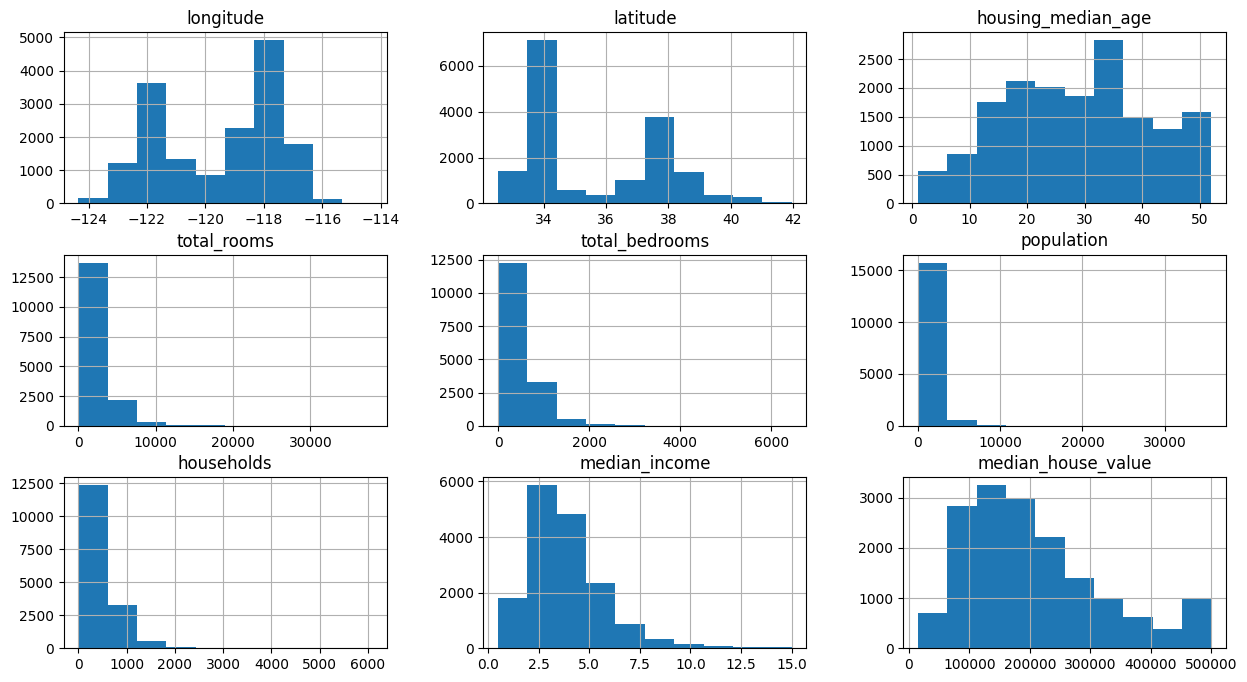

In [9]:
train_data.hist(figsize=(15,8))

In [10]:
numeric_train_data = train_data.drop(columns=["ocean_proximity"])
numeric_train_data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924154,-0.117180,0.046315,0.068412,0.097259,0.054275,-0.014144,-0.046750
latitude,-0.924154,1.000000,0.019447,-0.037728,-0.065947,-0.107484,-0.070695,-0.081895,-0.143442
housing_median_age,-0.117180,0.019447,1.000000,-0.361978,-0.323111,-0.295141,-0.305136,-0.122252,0.108073
total_rooms,0.046315,-0.037728,-0.361978,1.000000,0.932099,0.852625,0.919133,0.202220,0.135623
total_bedrooms,0.068412,-0.065947,-0.323111,0.932099,1.000000,0.871348,0.977766,-0.003301,0.050750
population,0.097259,-0.107484,-0.295141,0.852625,0.871348,1.000000,0.903380,0.009234,-0.025361
households,0.054275,-0.070695,-0.305136,0.919133,0.977766,0.903380,1.000000,0.017951,0.066156
median_income,-0.014144,-0.081895,-0.122252,0.202220,-0.003301,0.009234,0.017951,1.000000,0.689780
median_house_value,-0.046750,-0.143442,0.108073,0.135623,0.050750,-0.025361,0.066156,0.689780,1.000000


<Axes: >

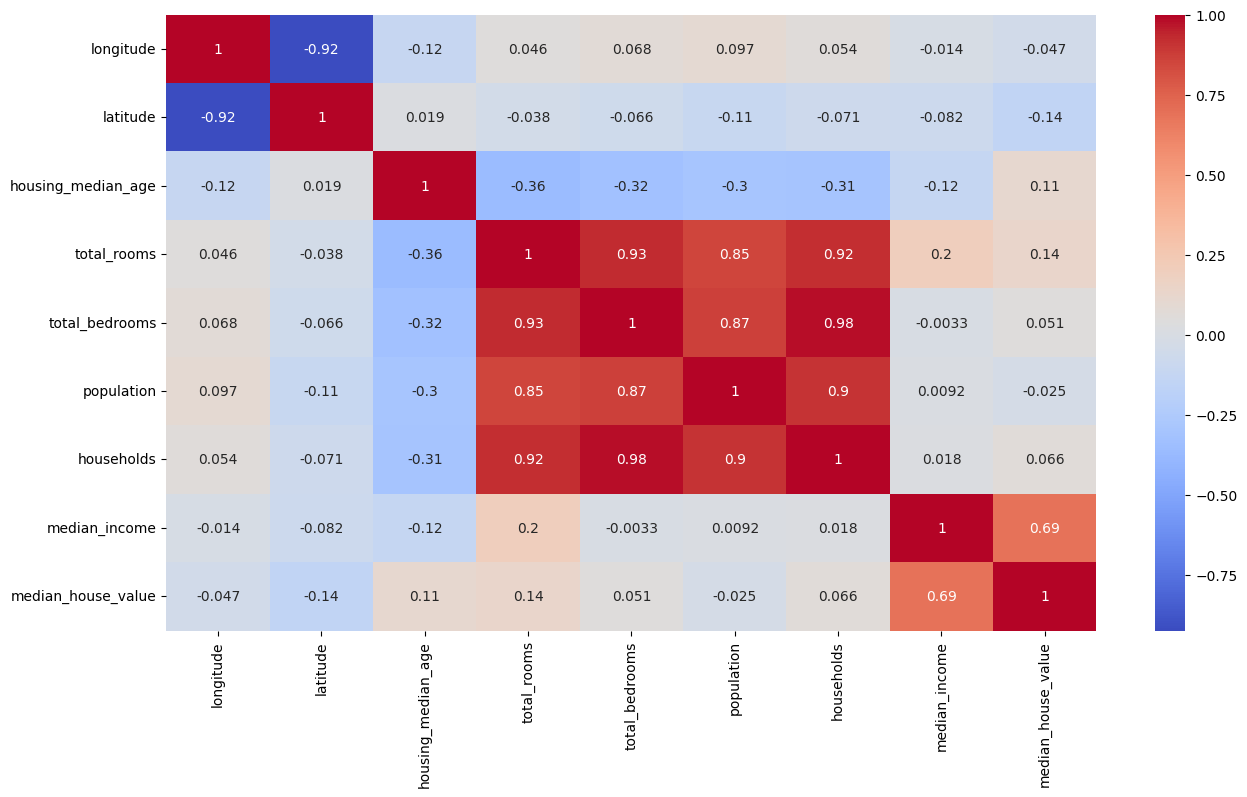

In [11]:
plt.figure(figsize=(15,8))             #must be befor
sns.heatmap(numeric_train_data.corr(),annot=True,cmap="coolwarm")   
#from this plot we could see which has a great relation with the target like the median_income is a very imp variable to look at and could be a great predictor to the median_house_value unlike the longitude has a -ve corr with the median_house_value

## Now the Pre_Processing


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

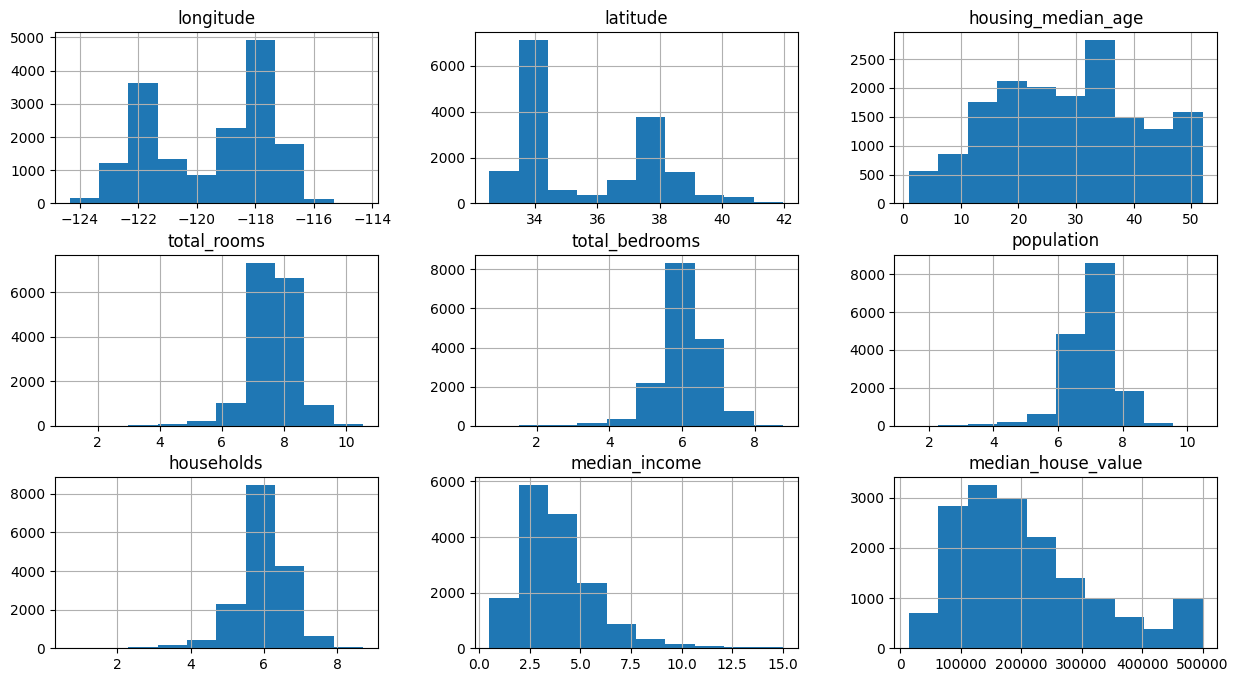

In [12]:
#applying the natural logarithm function to the values in the columns -which have skewed distr- with an additional 1 added to each value before taking the logarithm.
#Taking the logarithm of a variable can help to normalize its distribution, making it more suitable for certain statistical analyses or machine learning algorithms.
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

train_data.hist(figsize=(15,8))

#ocean_proximity is an imp feature but we have to make it numerical 

In [13]:
#we are going to classifay each feature 
pd.get_dummies(train_data.ocean_proximity)
train_data.join(pd.get_dummies(train_data.ocean_proximity))
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

In [14]:
plt.figure(figsize=(15,8))            
sns.heatmap(train_data.corr(),annot=True,cmap="coolwarm")  

<Axes: xlabel='latitude', ylabel='longitude'>

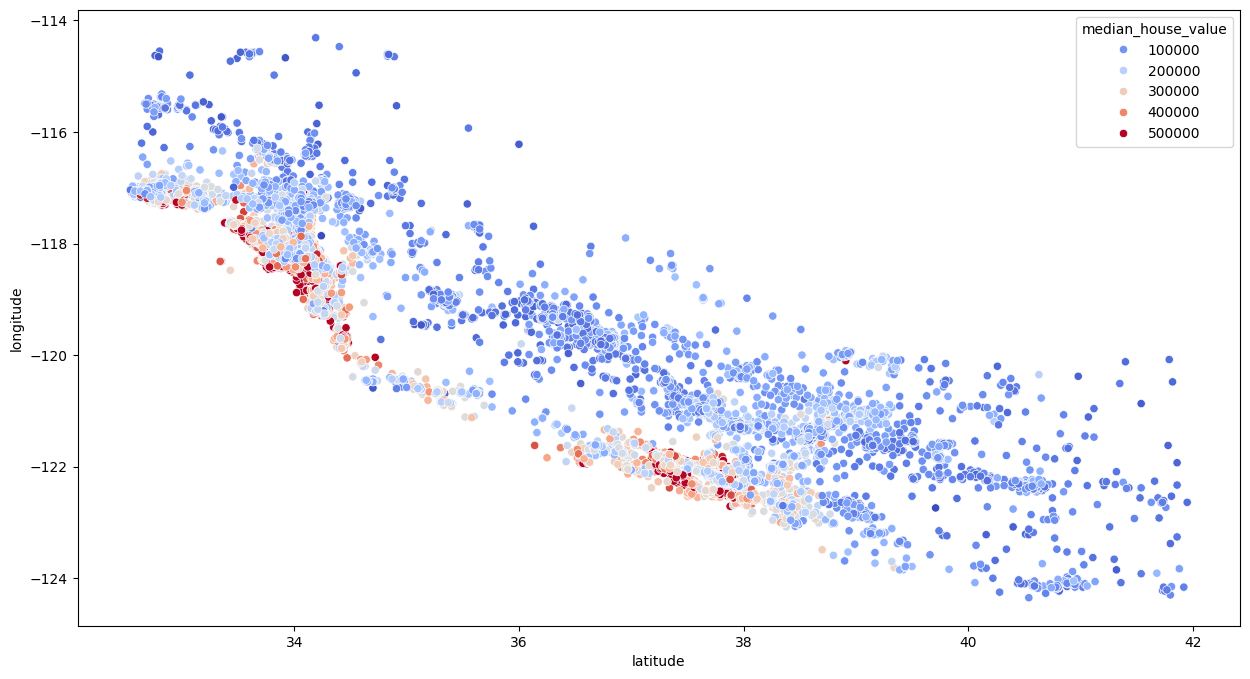

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude',y='longitude',data=train_data,hue='median_house_value',palette='coolwarm')

## Taking some features and combine them into new features (Features engineering)

In [ ]:
#how many of this rooms are bedrooms
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
#there could be many houshold than usual in the house so needs more rooms
train_data['households_ratio'] = train_data['total_rooms']/train_data['households']

#after the plot we will observe that featuers like the households and total_bedrooms were  not useful for the prediction while the new featuers got an interesting correlation

<Axes: >

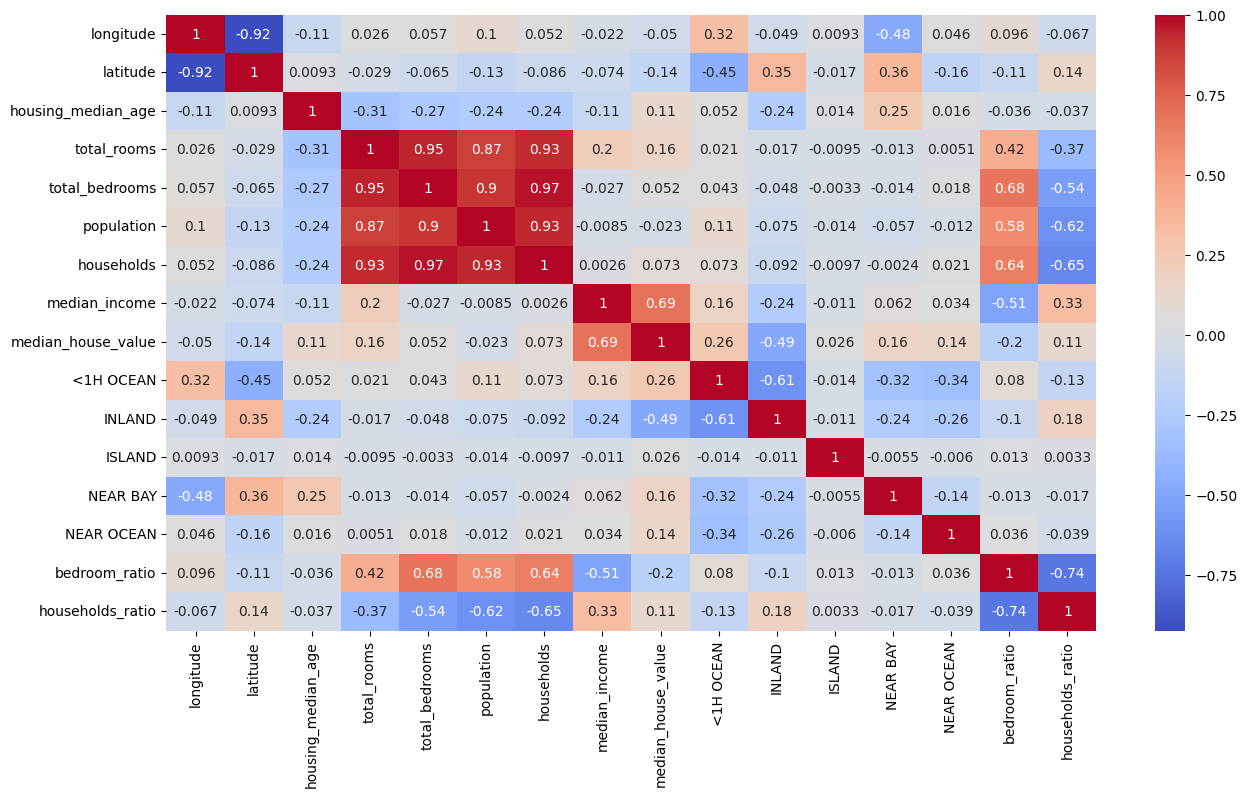

In [ ]:
plt.figure(figsize=(15,8))            
sns.heatmap(train_data.corr(),annot=True,cmap="coolwarm")  

## The simplest model to train is a simple linear regresstion

In [ ]:
from sklearn.linear_model import LinearRegression

#we have to split x and y again as we add new featuers 
x_train , y_train = train_data.drop(['median_house_value'],axis=1) , train_data['median_house_value']

reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
#we should scale the data
#but first we will see how this performs on the test data

test_data = x_test.join(y_test)   #preprocessing for test data ... in larger projects we put them in a fn and call it
test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)
test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)
test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['households_ratio'] = test_data['total_rooms']/test_data['households']


In [ ]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,households_ratio
8073,-118.18,33.83,52.0,7.851661,6.184149,6.938284,6.113682,4.1301,268400.0,False,False,False,False,True,0.787623,1.284277
18668,-121.91,36.99,23.0,8.644002,6.872128,7.695303,6.781058,4.8693,322300.0,False,False,False,False,True,0.795017,1.274728
17515,-121.93,37.33,44.0,7.279319,5.676754,6.517671,5.645447,3.5750,292200.0,True,False,False,False,False,0.779847,1.289414
3552,-118.61,34.23,26.0,8.223627,6.350886,7.452982,6.274762,6.1419,327300.0,True,False,False,False,False,0.772273,1.310588
5878,-118.35,34.16,45.0,7.237778,5.641907,6.289716,5.602119,4.2212,293800.0,True,False,False,False,False,0.779508,1.291972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5265,-118.54,34.05,33.0,8.821585,6.996681,7.840313,6.959399,8.5650,500001.0,True,False,False,False,False,0.793132,1.267579
6827,-118.11,34.08,42.0,8.062433,6.469250,7.512071,6.466145,3.3966,243200.0,True,False,False,False,False,0.802394,1.246869
10815,-117.95,33.63,27.0,6.793466,5.214936,6.242223,5.147494,6.0000,381500.0,True,False,False,False,False,0.767640,1.319762
18525,-122.04,36.97,45.0,7.172425,5.505332,6.432940,5.556828,5.1806,266400.0,False,False,False,False,True,0.767569,1.290741


In [ ]:
x_test , y_test = test_data.drop(['median_house_value'],axis=1) , test_data['median_house_value']

In [ ]:
reg.score(x_test,y_test)        #the result 0.6676143652773974 is neither so bad nor so good we have to make it better

0.6676143652773974

## For better score we are going to use more powerful model the random forest regerssion 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
forest.score(x_test,y_test)     #we can see that the result  is better its 0.8162402081511901

0.8162402081511901

We want to get an even higher accuracy by providing a parameters grid and trying diff options using Grid Search with cross validation 
(its a technique used in ml to search and find the optimal combination of hyperparameters for a given model)

To improve the quality of model:
- we can go with simple decision tree
- we can train a neural network
- we can play around with the gridsearch for better score
- we can engineer diff feauters
- we can drop feauters